In [5]:
!pip install langchain langchain-core langchain-community langchain-groq langgraph -q


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## BMI Calculator

In [12]:
# Define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [8]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height ** 2)

    state["bmi"] = round(bmi, 2)

    return state

In [13]:
def find_bmi_category(state: BMIState) -> BMIState:

    bmi = state["bmi"]

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [14]:
# Define graph
graph = StateGraph(BMIState)

# Add nodes to your graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("find_bmi_category", find_bmi_category)

# Add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "find_bmi_category")
graph.add_edge("find_bmi_category", END)

# Compile Graph to check structure of graph
workflow = graph.compile()

In [15]:
# Execute graph
initial_state = {
    "weight_kg" : 103,
    "height_m": 1.93
}

output_state = workflow.invoke(initial_state)

output_state


{'weight_kg': 103, 'height_m': 1.93, 'bmi': 27.65, 'category': 'Overweight'}

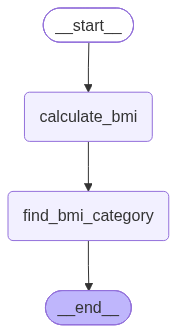

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())